# Where a function's time goes (Grid'5000)

Per compute work operator: share of the billed wall time spent on dispatch and on its input, compute and output
demand, and how much of the 2 vCPU it uses (above each bar). Data: `cost-stages.jsonl` of the BLOOM-FaaS S3 runs
(default `history-v6`).

Caption note: *Input demand* is the function's own input download (S3 for scans, NFS Bloom filters for Merge BF);
*Compute demand* is DuckDB / Bloom-filter work and, for joins and aggregates, includes DuckDB reading its inputs
from S3 — hence a join spends 86% of its time on compute demand while using only ~20% of its CPU.

In [34]:
RUNS     = "../history-v6/q*/*--bloomfaas-s3*"   # glob of run folders (BF on, S3 shuffle)
OUT_DIR  = "cost-report/tpch100-v5/s3grid"
OUT_NAME = "task-profile-g5k"

## Style và dữ liệu

In [35]:
import os, glob, json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
%matplotlib inline

fm.fontManager.addfont("./fonts/LinLibertine_R.otf")
plt.rcParams['font.family'] = 'Linux Libertine O'
plt.rcParams['font.serif'] = ['Linux Libertine O']
FONT_SIZE = 13
plt.rcParams['font.size'] = FONT_SIZE
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams.update({"pdf.fonttype": 42, "ps.fonttype": 42, "axes.unicode_minus": True,
                     "text.color": "black", "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black"})
GRID = "#e4e3df"
DPI = 300
TYPES = {"/scan-bloomfaas": "Scan", "/join": "Join", "/aggregate": "Aggregate", "/merge-bf": "Merge BF"}
# Input demand = the function's own input download (S3 for scans, NFS Bloom filters for merge BF);
# Compute demand = DuckDB / BF work, which for joins and aggregates also includes DuckDB reading its inputs from S3;
# Output demand = writing the function's output.
PARTS = [("disp", "Dispatch", "#c9c8c2"), ("t_read", "Input demand", "#2a78d6"),
         ("t_comp", "Compute demand", "#eb6834"), ("t_write", "Output demand", "#1baf7a")]


def save(fig, name):
    for ext in ("pdf", "png"):
        fig.savefig(os.path.join(OUT_DIR, f"{name}.{ext}"), dpi=DPI, bbox_inches="tight", pad_inches=0.02)


# totals per function type: seconds in each part, CPU seconds, vCPU, number of tasks and runs
tot = defaultdict(lambda: defaultdict(float))
runs = [d for d in glob.glob(RUNS) if os.path.exists(os.path.join(d, "cost-stages.jsonl"))]
cold = n_all = 0
for d in runs:
    for line in open(os.path.join(d, "cost-stages.jsonl")):
        for t in json.loads(line)["tasks"]:
            n_all += 1
            cold += bool(t.get("cold"))
            e = TYPES.get(t.get("endpoint"))
            if not e:
                continue
            x = tot[e]
            for k, _, _ in PARTS:
                x[k] += t.get(k, 0.0)
            x["wall"] += t.get("t_total", 0.0) + t.get("disp", 0.0)
            x["cpu_s"] += t.get("cpu_s", 0.0)
            x["vcpu_s"] += t.get("cpu", 2.0) * t.get("t_total", 0.0)
            x["n"] += 1
print(f"{len(runs)} runs, {n_all} tasks, cold starts {cold} ({100 * cold / max(n_all, 1):.2f}%)")
for e, x in tot.items():
    shares = " ".join(f"{lab} {100 * x[k] / x['wall']:.0f}%" for k, lab, _ in PARTS)
    print(f"  {e:9} {int(x['n']):7} tasks  {shares}  CPU {100 * x['cpu_s'] / x['vcpu_s']:.0f}% of the vCPUs")

285 runs, 86604 tasks, cold starts 0 (0.00%)
  Scan        45645 tasks  Dispatch 4% Input demand 61% Compute demand 10% Output demand 26%  CPU 18% of the vCPUs
  Aggregate   15001 tasks  Dispatch 2% Input demand 0% Compute demand 52% Output demand 46%  CPU 29% of the vCPUs
  Merge BF      510 tasks  Dispatch 11% Input demand 48% Compute demand 28% Output demand 14%  CPU 37% of the vCPUs
  Join        25163 tasks  Dispatch 4% Input demand 0% Compute demand 86% Output demand 10%  CPU 20% of the vCPUs


## Hình: phân rã thời gian và mức dùng CPU theo compute work operator (cột đứng, một cột)

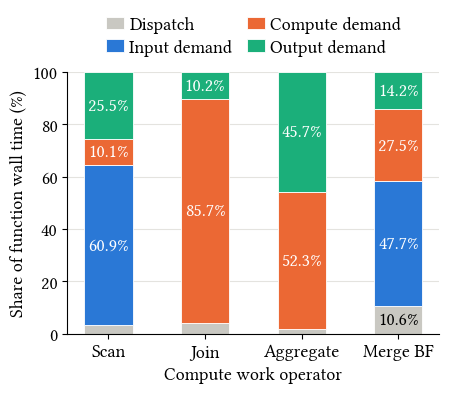

In [36]:
FIGSIZE = (4.8, 3.4)
ORDER   = ["Scan", "Join", "Aggregate", "Merge BF"]
LEGEND  = True
XLABEL  = "Compute work operator"

types = [e for e in ORDER if e in tot]
fig, ax = plt.subplots(figsize=FIGSIZE)
bottom = np.zeros(len(types))
for k, lab, col in PARTS:
    v = np.array([100 * tot[e][k] / tot[e]["wall"] for e in types])
    ax.bar(range(len(types)), v, bottom=bottom, color=col, edgecolor="white", lw=0.6, width=0.5, label=lab)
    for i, (b, h) in enumerate(zip(bottom, v)):
        if h >= 8:
            ax.text(i, b + h / 2, f"{h:.1f}%", ha="center", va="center", fontsize=FONT_SIZE,
                    color="white" if col != "#c9c8c2" else "black")
    bottom += v
# for i, e in enumerate(types):   # CPU use above each bar
#     ax.text(i, 101.5, f"CPU {100 * tot[e]['cpu_s'] / tot[e]['vcpu_s']:.0f}%", ha="center", va="bottom",
#             fontsize=FONT_SIZE - 3, color="#52514e")
ax.set_xticks(range(len(types)), types)
ax.set_xlabel(XLABEL)
ax.set_ylim(0, 100)
ax.set_ylabel("Share of function wall time (%)")
ax.grid(True, axis="y", color=GRID)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
if LEGEND:
    ax.legend(ncol=2, loc="lower center", bbox_to_anchor=(0.5, 1.0), frameon=False, fontsize=FONT_SIZE,
              handlelength=1.0, handletextpad=0.3, columnspacing=0.8, labelspacing=0.3)
save(fig, OUT_NAME)